<a href="https://colab.research.google.com/github/Rima6699/Amir-datmin/blob/main/2304020182_M_A_Husain_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

import seaborn as sb

import matplotlib.pyplot as plt


In [19]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [22]:
student_performance_dataset = df.copy()
student_performance_dataset

,Student ID,Gender,Race/Ethnicity,Parental Education,Lunch Type,Test Preparation,Study Time per Week,Daily Sleep Duration,Math Score,Reading Score,Writing Score,School Type,Internet Access
0,1,female,group B,some college,standard,False,12.40,5.40,62.00,76.00,65.00,public,True
1,2,male,group D,high school,standard,False,18.30,5.10,74.00,73.00,76.00,public,NaN
2,3,male,group B,bachelor degree,free/reduced,True,11.80,7.80,71.00,83.00,91.00,public,False
3,4,male,group E,high school,standard,False,NaN,7.30,83.00,73.00,52.00,public,True
4,5,female,group C,bachelor degree,standard,True,12.90,6.30,41.00,NaN,81.00,public,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,6996,female,group C,some college,standard,True,3.50,6.80,74.00,NaN,50.00,private,False
6996,6997,female,group A,associate degree,free/reduced,True,10.80,7.30,82.00,52.00,81.00,public,True
6997,6998,female,group C,high school,standard,False,12.70,6.90,78.00,NaN,59.00,public,True
6998,6999,male,group D,high school,standard,True,15.10,8.10,62.00,63.00,79.00,public,True


<Axes: xlabel='Math Score', ylabel='Reading Score'>

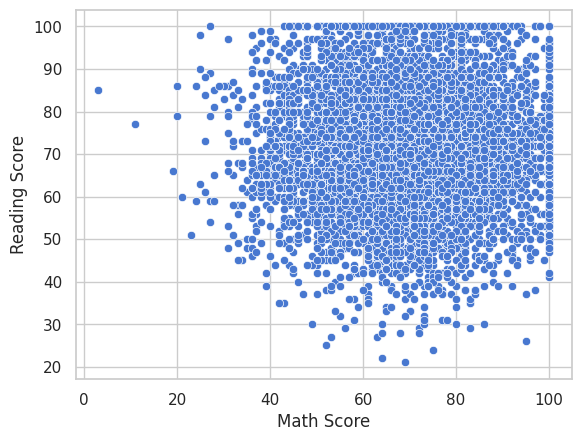

In [24]:
sb.scatterplot(
    x= student_performance_dataset['Math Score'],
    y= student_performance_dataset['Reading Score']
)

<Axes: xlabel='Math Score', ylabel='Reading Score'>

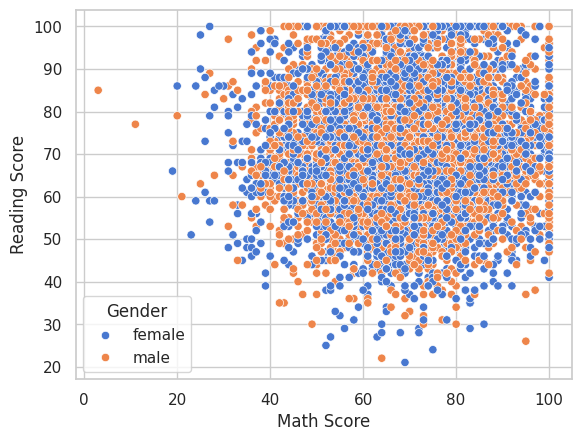

In [27]:
sb.scatterplot(
    x= student_performance_dataset['Math Score'],
    y= student_performance_dataset['Reading Score'],
    hue= student_performance_dataset['Gender']
)

CLUSTERING EXPERIMEN

K-MEAN STUDENT PERFORMANNCE

In [28]:
from sklearn.cluster import KMeans

In [33]:
X = student_performance_dataset[['Math Score', 'Reading Score']]
X = X.dropna()
X

,Math Score,Reading Score
0,62.00,76.00
1,74.00,73.00
2,71.00,83.00
3,83.00,73.00
7,65.00,86.00
...,...,...
6993,56.00,74.00
6994,70.00,70.00
6996,82.00,52.00
6998,62.00,63.00


In [34]:
kmeans_model = KMeans(n_clusters= 3, random_state=0, n_init='auto')
kmeans_model.fit(X)

KMeans(n_clusters=3, random_state=0)

In [35]:
kmeans_model.labels_

array([2, 0, 2, ..., 0, 1, 2], dtype=int32)

In [36]:
X['cluster_pred'] = kmeans_model.labels_
X

,Math Score,Reading Score,cluster_pred
0,62.00,76.00,2
1,74.00,73.00,0
2,71.00,83.00,2
3,83.00,73.00,0
7,65.00,86.00,2
...,...,...,...
6993,56.00,74.00,1
6994,70.00,70.00,0
6996,82.00,52.00,0
6998,62.00,63.00,1


<Axes: xlabel='Math Score', ylabel='Reading Score'>

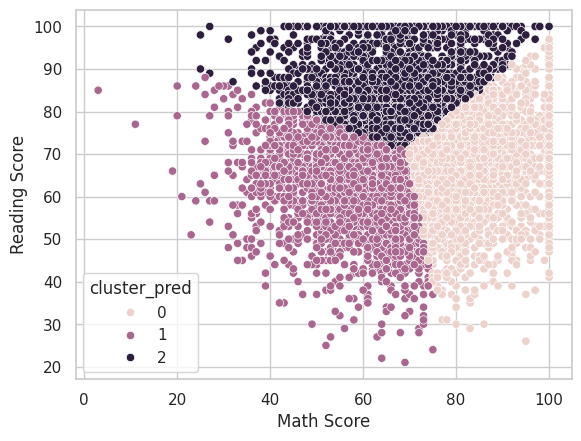

In [38]:
sb.scatterplot(
    x= X['Math Score'],
    y=  X['Reading Score'],
    hue= X.cluster_pred
)

In [56]:
n_cluster_list = np.arange(2, 11, 1) # daftar eksperimen jumlah cluster
clustering_models = [KMeans(n_clusters= cluster).fit(X) for cluster in n_cluster_list] # daftar model KMeans yang telah dilatih pada data
centroids_list = [cluster_model.cluster_centers_ for cluster_model in clustering_models] # daftar posisi centroid

In [ ]:
from scipy.spatial.distance import cdist

Untuk mencari jumlah cluster yg optimum bisa dengan melihat average within-cluster sum of squares (SS), yang menunjukkan rata-rata jarak (squared distance) setiap titik data ke centroid terdekat. Nilai ini menggambarkan seberapa erat titik-titik data di dalam klaster, di mana semakin kecil nilai ini, semakin baik klasterisasi.

In [61]:
distances_to_centroid = [cdist(X, centroid, 'euclidean') for centroid in centroids_list]
cIdx = [np.argmin(D, axis=1) for D in distances_to_centroid]
distance_list = [np.min(D, axis=1) for D in distances_to_centroid]
avgWithinSS = [sum(d)/X.shape[0] for d in distance_list]

Text(0, 0.5, 'Sum Squared Error')

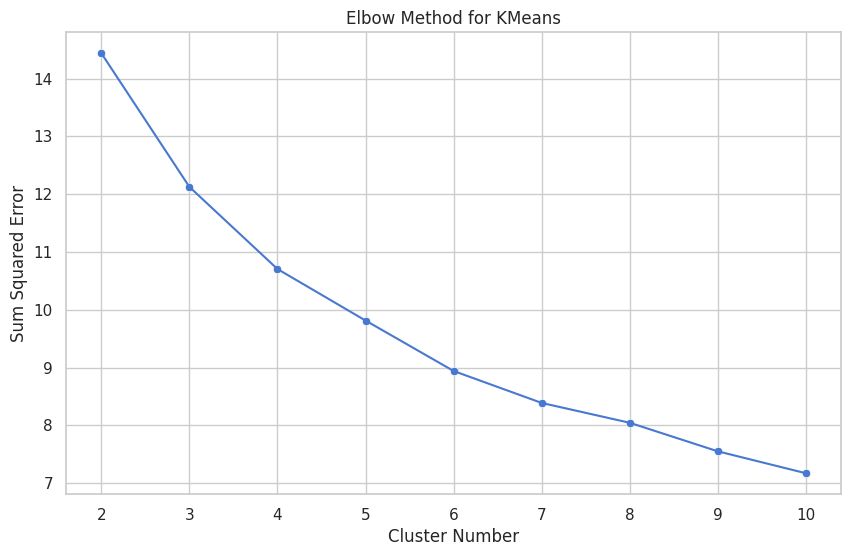

In [62]:
plt.figure(figsize= (10, 6))
sb.lineplot(
    x= n_cluster_list,
    y = avgWithinSS
)
sb.scatterplot(
    x= n_cluster_list,
    y = avgWithinSS
)

plt.title("Elbow Method for KMeans")
plt.xlabel("Cluster Number")
plt.ylabel("Sum Squared Error")

In [63]:
best_kmeans = KMeans(n_clusters= 3)
best_kmeans.fit(X)

KMeans(n_clusters=3)

In [64]:
X['cluster'] = best_kmeans.labels_
X

,Math Score,Reading Score,cluster_pred,cluster
0,62.00,76.00,2,1
1,74.00,73.00,0,2
2,71.00,83.00,2,2
3,83.00,73.00,0,2
7,65.00,86.00,2,1
...,...,...,...,...
6993,56.00,74.00,1,1
6994,70.00,70.00,0,0
6996,82.00,52.00,0,0
6998,62.00,63.00,1,0


<Axes: xlabel='Math Score', ylabel='Reading Score'>

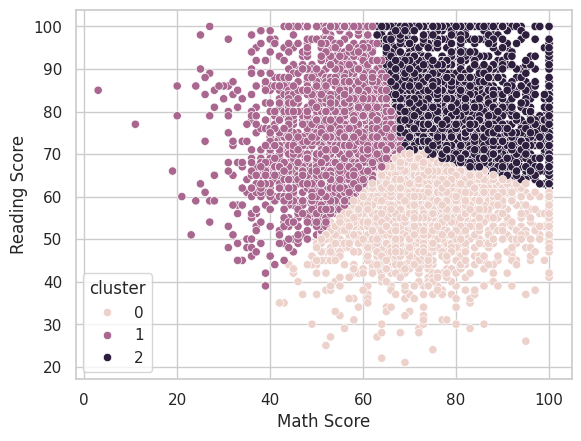

In [66]:
sb.scatterplot(
    x= X['Math Score'],
    y= X['Reading Score'],
    hue= X.cluster
)

SILLHOUTE SCORE

In [67]:
from sklearn.metrics import silhouette_score

In [69]:
X_sample = X.head(200)

In [71]:
best_kmeans = KMeans(n_clusters= 3)
best_kmeans.fit(X_sample)

silhouette = silhouette_score(
    X= X_sample,
    labels= best_kmeans.labels_,
)

print("Silhouette Score of K-Means: {}".format(silhouette))

Silhouette Score of K-Means: 0.31370148673033393


In [72]:
n_cluster_list = np.arange(2, 11, 1) # daftar eksperimen jumlah cluster
silhouette_score_list = []

for cluster in n_cluster_list:
    kmeans = KMeans(n_clusters= cluster)
    kmeans.fit(X_sample)

    silhouette_score_list.append(silhouette_score(X= X_sample,labels= kmeans.labels_))

In [73]:
n_cluster_experiments = pd.DataFrame({
    'Number of Cluster' : n_cluster_list,
    'Silhouette Score': silhouette_score_list
})

n_cluster_experiments = n_cluster_experiments.sort_values(by= 'Silhouette Score', ascending= False)
n_cluster_experiments


##pakai pseudo f

,Number of Cluster,Silhouette Score
4,6,0.36
5,7,0.36
2,4,0.34
0,2,0.34
8,10,0.33
7,9,0.33
1,3,0.33
6,8,0.33
3,5,0.31


Text(0, 0.5, 'Sillhouette Score')

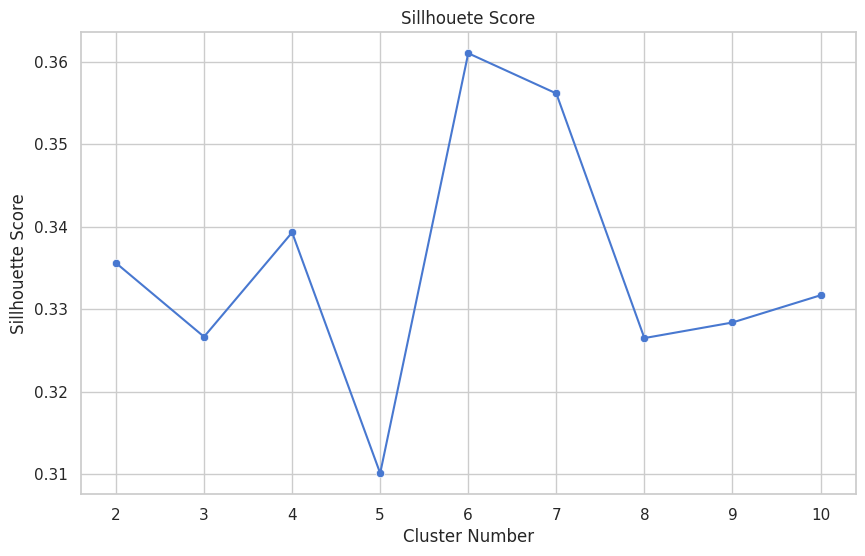

In [74]:
plt.figure(figsize= (10, 6))
sb.lineplot(
    x= n_cluster_list,
    y = silhouette_score_list
)
sb.scatterplot(
    x= n_cluster_list,
    y = silhouette_score_list
)

plt.title("Sillhouete Score")
plt.xlabel("Cluster Number")
plt.ylabel("Sillhouette Score")

algoritma clustering


In [75]:
from sklearn.cluster import AgglomerativeClustering

In [80]:
# define the model
ward_agglomerative = AgglomerativeClustering(n_clusters= 3, linkage= 'ward') # minimize the variance
average_agglomerative = AgglomerativeClustering(n_clusters= 3, linkage= 'average') # average the distance
complete_agglomerative = AgglomerativeClustering(n_clusters= 3, linkage= 'complete') # maximize the variance
min_agglomerative = AgglomerativeClustering(n_clusters= 3, linkage= 'single') # minimize the distance

# define the features
X = student_academic_performance

In [85]:
# Gunakan data numerik yang sudah dibersihkan (Math & Reading Score)
X_clustering = student_performance_dataset[['Math Score', 'Reading Score']].dropna()

# fit model
ward_agglomerative.fit(X_clustering)
average_agglomerative.fit(X_clustering)
complete_agglomerative.fit(X_clustering)
min_agglomerative.fit(X_clustering)

print("Semua model Agglomerative berhasil dilatih.")

Semua model Agglomerative berhasil dilatih.


In [86]:
ward_agglomerative.labels_

array([2, 1, 0, ..., 1, 1, 0])

In [87]:
# Menambahkan hasil label cluster ke dataframe X_clustering
X_clustering['ward_cluster_label'] = ward_agglomerative.labels_
X_clustering['average_cluster_label'] = average_agglomerative.labels_
X_clustering['complete_cluster_label'] = complete_agglomerative.labels_
X_clustering['min_cluster_label'] = min_agglomerative.labels_
X_clustering.head()

,Math Score,Reading Score,ward_cluster_label,average_cluster_label,complete_cluster_label,min_cluster_label
0,62.00,76.00,2,2,0,0
1,74.00,73.00,1,2,0,0
2,71.00,83.00,0,2,0,0
3,83.00,73.00,0,2,0,0
7,65.00,86.00,0,2,0,0


In [89]:
X

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.10,3.50,1.40,0.20,setosa
1,4.90,3.00,1.40,0.20,setosa
2,4.70,3.20,1.30,0.20,setosa
3,4.60,3.10,1.50,0.20,setosa
4,5.00,3.60,1.40,0.20,setosa
...,...,...,...,...,...
145,6.70,3.00,5.20,2.30,virginica
146,6.30,2.50,5.00,1.90,virginica
147,6.50,3.00,5.20,2.00,virginica
148,6.20,3.40,5.40,2.30,virginica


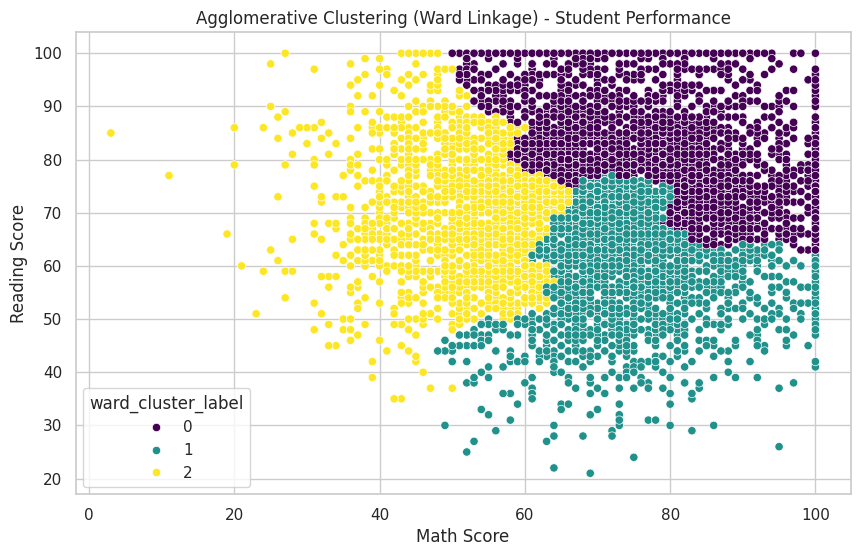

In [88]:
plt.figure(figsize=(10, 6))
sb.scatterplot(
    x=X_clustering['Math Score'],
    y=X_clustering['Reading Score'],
    hue=X_clustering['ward_cluster_label'],
    palette='viridis'
)

plt.title("Agglomerative Clustering (Ward Linkage) - Student Performance")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.show()

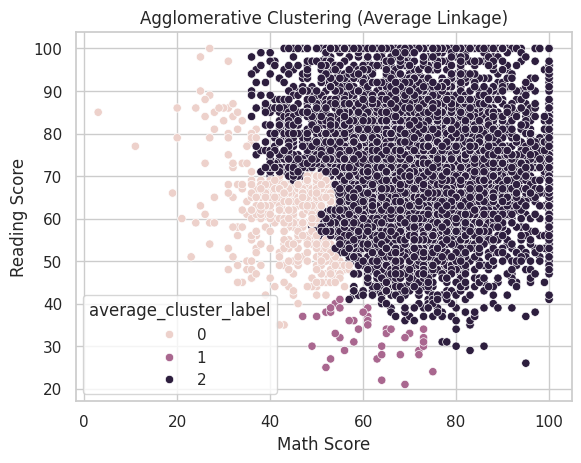

In [93]:
sb.scatterplot(
    x= X_clustering['Math Score'],
    y= X_clustering['Reading Score'],
    hue= X_clustering.average_cluster_label
)

plt.title("Agglomerative Clustering (Average Linkage)")
plt.show()

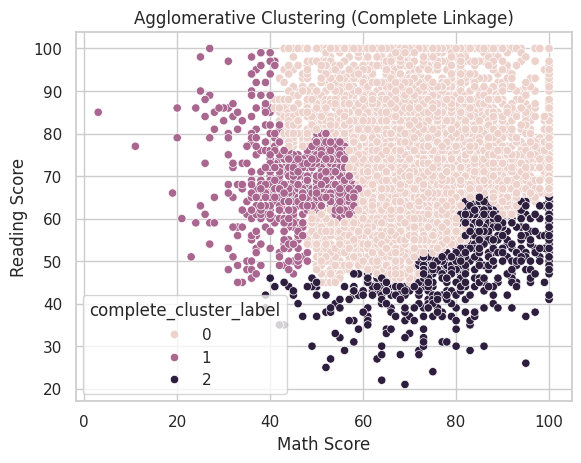

In [100]:
sb.scatterplot(
    x=X_clustering['Math Score'],
    y=X_clustering['Reading Score'],
    hue=X_clustering['complete_cluster_label']
)

plt.title("Agglomerative Clustering (Complete Linkage)")
plt.show()

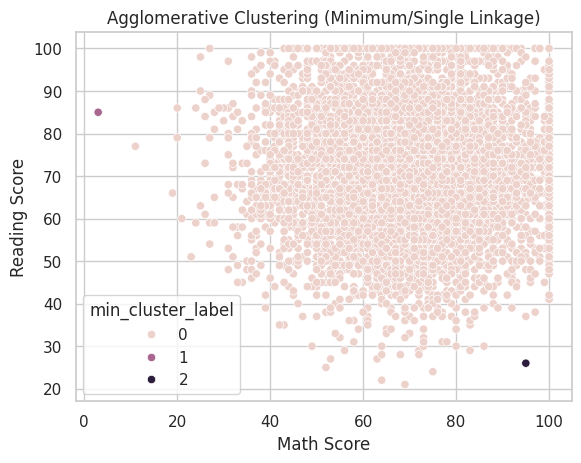

In [95]:
sb.scatterplot(
    x= X_clustering['Math Score'],
    y= X_clustering['Reading Score'],
    hue= X_clustering.min_cluster_label
)

plt.title("Agglomerative Clustering (Minimum/Single Linkage)")
plt.show()

In [101]:
# Re-fit models on X_sample to ensure consistent lengths for evaluation
ward_agglomerative.fit(X_sample)
average_agglomerative.fit(X_sample)
complete_agglomerative.fit(X_sample)
min_agglomerative.fit(X_sample)

sillhouette_ward = silhouette_score(X=X_sample, labels=ward_agglomerative.labels_)
sillhouette_average = silhouette_score(X=X_sample, labels=average_agglomerative.labels_)
sillhouette_max = silhouette_score(X=X_sample, labels=complete_agglomerative.labels_)
sillhouette_min = silhouette_score(X=X_sample, labels=min_agglomerative.labels_)

print("Silhouette Score using Agglomerative with Ward Technique: {}".format(sillhouette_ward))
print("Silhouette Score using Agglomerative with Average Technique: {}".format(sillhouette_average))
print("Silhouette Score using Agglomerative with Max (complete) Technique: {}".format(sillhouette_max))
print("Silhouette Score using Agglomerative with Min Technique: {}".format(sillhouette_min))

Silhouette Score using Agglomerative with Ward Technique: 0.3249828569978611
Silhouette Score using Agglomerative with Average Technique: 0.35552471298648713
Silhouette Score using Agglomerative with Max (complete) Technique: 0.2638595577520224
Silhouette Score using Agglomerative with Min Technique: 0.35527077710992144


In [104]:
# Pastikan X menggunakan data numerik dari dataset siswa
X = student_performance_dataset[['Math Score', 'Reading Score']].dropna()

kmeans_model = KMeans(n_clusters=3, n_init='auto')
kmeans_model.fit(X)

sillhouette_kmeans = silhouette_score(X=X, labels=kmeans_model.labels_)
print("Silhouette Score using KMeans: {}".format(sillhouette_kmeans))

Silhouette Score using KMeans: 0.33199159826564223


COMPARES AGGLOMERATIVE AND KMEANS

In [103]:
X = student_performance_dataset[['Math Score', 'Reading Score']]
X

,Math Score,Reading Score
0,62.00,76.00
1,74.00,73.00
2,71.00,83.00
3,83.00,73.00
4,41.00,NaN
...,...,...
6995,74.00,NaN
6996,82.00,52.00
6997,78.00,NaN
6998,62.00,63.00


In [105]:
best_kmeans = KMeans(n_clusters= 3)
best_kmeans.fit(X_sample)

silhouette = silhouette_score(
    X= X_sample,
    labels= best_kmeans.labels_,
)

print("Silhouette Score of K-Means: {}".format(silhouette))

Silhouette Score of K-Means: 0.32128928817901925


In [106]:
# define the model
ward_agglomerative = AgglomerativeClustering(n_clusters= 3, linkage= 'ward') # minimize the variance
average_agglomerative = AgglomerativeClustering(n_clusters= 3, linkage= 'average') # average the distance
complete_agglomerative = AgglomerativeClustering(n_clusters= 3, linkage= 'complete') # maximize the variance
min_agglomerative = AgglomerativeClustering(n_clusters= 3, linkage= 'single') # minimize the distance

# fit model
ward_agglomerative.fit(X_sample)
average_agglomerative.fit(X_sample)
complete_agglomerative.fit(X_sample)
min_agglomerative.fit(X_sample)

AgglomerativeClustering(linkage='single', n_clusters=3)

In [107]:
sillhouette_ward = silhouette_score(X=X_sample, labels= ward_agglomerative.labels_)
sillhouette_average = silhouette_score(X= X_sample, labels= average_agglomerative.labels_)
sillhouette_max = silhouette_score(X= X_sample, labels= complete_agglomerative.labels_)
sillhouette_min = silhouette_score(X=X_sample, labels= min_agglomerative.labels_)

print("Sillhouette Score using Agglomerative with Ward Technique: {}".format(sillhouette_ward))
print("Sillhouette Score using Agglomerative with Average Technique: {}".format(sillhouette_average))
print("Sillhouette Score using Agglomerative with Max (complete) Technique: {}".format(sillhouette_max))
print("Sillhouette Score using Agglomerative with Min Technique: {}".format(sillhouette_min))

Sillhouette Score using Agglomerative with Ward Technique: 0.3249828569978611
Sillhouette Score using Agglomerative with Average Technique: 0.35552471298648713
Sillhouette Score using Agglomerative with Max (complete) Technique: 0.2638595577520224
Sillhouette Score using Agglomerative with Min Technique: 0.35527077710992144


Summary:
- Berdasarkan hasil eksperimen, algoritma Agglomerative Clustering dengan teknik minimum mampu menghasilkan nilai sillhouette paling tinggi
